# Icequake source mechanism workshop practical

Skience 2026

In [1]:
# Import neccessary modules:
import os, sys
import numpy as np
import obspy
from scipy.signal import periodogram, hilbert
from sklearn import linear_model
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import pyproj
# import glob
# import NonLinLocPy
from numba import jit
import SeisSrcInv
from obspy.imaging.beachball import beachball
import pickle
# import time
# import gc
#import cmcrameri.cm as cmc

# Import some useful functions:
from useful_functions import get_stf_and_attn_starting_model_params, ncc, mt_ned2use

###from run_salvus_sm_synthetics import gen_synths_salvus

# %matplotlib notebook
%matplotlib inline


/Users/tomhudson/Documents/projects/gornergletscher_2023/skience_workshop/workshop_practicals/extra_packages/SeisSrcInv/SeisSrcInv/plot.py:1684: SyntaxWarning: invalid escape sequence '\p'
  ax.set_ylabel('$\phi$ (rad)')


## 0. The data and the problem

### Data:

The dataset used here is a DAS dataset collected at Gornergletscher in October 2023. It consists of 600 m of fibreoptic cable sampling strain at every 1.6 m. The fibre was deployed in a 100 x 100 m grid over a crevasse field.

### The workshop problem:

The aim of this practical is to use a DAS dataset to invert for a crevasse icequake source mechanism. To do this, we will:
1. Understand the source-receiver geometry
2. Explore/familiarise ourselves with the DAS wavefield
3. Load in the neccessary full-waveform forward model data (note: we will not run any forward modelling here - it is rather computationally costly!)
4. Perform the inversion
5. Plot up the inversion results
6. Explore ways to improve or expand upon the inversion result and/or learn more about the source


### Skills learnt/experience gained:
- Exposure to fibreoptic sensing data
- Introduction to linear inversion
- Introduction to full waveform seismic source inversion


## 1. Explore the source-receiver geometry

- Read in the receivers information
- Read in the source information
- Plot up the sources and receiver geometry

In [2]:
# Load in receiver information:
receivers_fname = "inputs/gornerglethscer_das_and_nodes_qm_stations.csv"

# Import receivers and convert to cartesian coordinates:
gproj = pyproj.Proj(proj="lcc", units="km", lon_0=7.817, lat_0=45.9793, lat_1=45.979,
             lat_2=45.9796, datum="WGS84", ellps="WGS84", no_defs=True)
cproj = pyproj.Proj(proj="longlat", datum="WGS84", ellps="WGS84", no_defs=True)
latlon_to_km_conv = pyproj.Transformer.from_proj(cproj, gproj)
receivers_df = pd.read_csv(receivers_fname)
x_km, y_km = latlon_to_km_conv.transform(receivers_df['Longitude'].values, receivers_df['Latitude'].values)
receivers_df['x_m'] = x_km * 1000
receivers_df['y_m'] = y_km * 1000
receivers_df['z_m'] = 0.

# And remove nodes:
# receivers_df = receivers_df[~receivers_df.Name.str.contains("N")] # Remove nodes

print("Receiver dataframe:")
display(receivers_df)

Receiver dataframe:


,Latitude,Longitude,Elevation,Name,x_m,y_m,z_m
0,45.979632,7.816233,2.723304,D0379,-59.414850,36.890073,0.0
1,45.979632,7.816255,2.723825,D0381,-57.742695,36.929342,0.0
2,45.979633,7.816276,2.724347,D0382,-56.070539,36.968612,0.0
3,45.979633,7.816298,2.724868,D0384,-54.398383,37.007882,0.0
4,45.979633,7.816320,2.725389,D0386,-52.726227,37.047152,0.0
...,...,...,...,...,...,...,...
421,45.978794,7.817073,2.753944,N25,5.653274,-56.189029,0.0
422,45.978786,7.817320,2.749990,N26,24.769178,-57.111321,0.0
423,45.979116,7.817288,2.746234,N27,22.339773,-20.506561,0.0
424,45.979277,7.817285,2.748375,N28,22.092886,-2.604788,0.0


In [3]:
# Load in source information:
fname_in = os.path.join("inputs", "loc.Tom__RunNLLoc000.20231022.080438.grid0.loc.pythonpkl")
nlloc_hyp_data = pickle.load(open(fname_in, 'rb'))

event_uid = str(nlloc_hyp_data.origin_time).replace('-','').replace(':','').replace('.','').replace('T','').replace('Z','')

# Convert source to cartesian coordinates:
src_lonlat = [nlloc_hyp_data.max_prob_hypocenter['lon'], nlloc_hyp_data.max_prob_hypocenter['lat']]
z_km_src = -10.0 / 1000 # Source at 10 metres from surface (as positive up)
x_km_src, y_km_src = latlon_to_km_conv.transform(src_lonlat[0], src_lonlat[1])
xyz_src_m = np.array([x_km_src, y_km_src, z_km_src]) * 1000



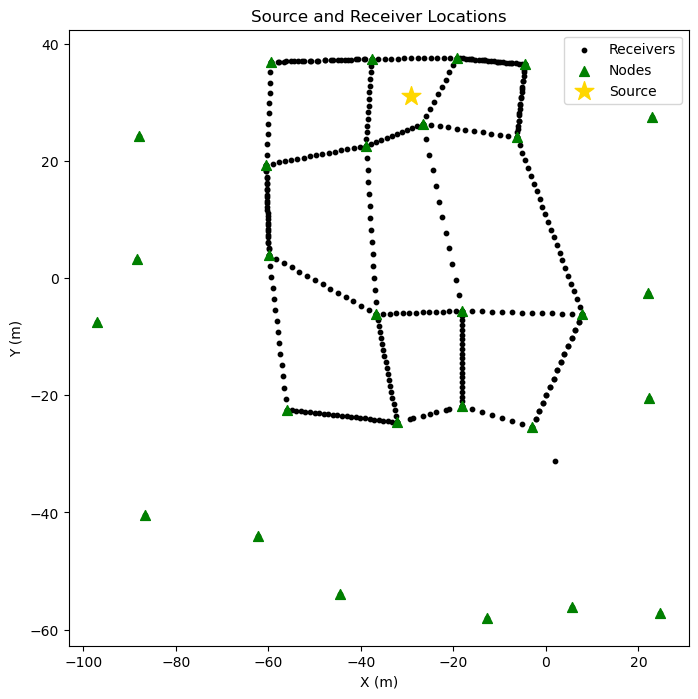

In [4]:
# Plot sources and receivers on a map:
fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(receivers_df['x_m'], receivers_df['y_m'], c='k', s=10, label='Receivers')
receivers_df_nodes_only = receivers_df[receivers_df.Name.str.contains("N")] # Get nodes only
ax.scatter(receivers_df_nodes_only['x_m'], receivers_df_nodes_only['y_m'], c='green', s=50, marker="^", label='Nodes')
ax.scatter(xyz_src_m[0], xyz_src_m[1], c='gold', marker='*', s=200, label='Source')
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title("Source and Receiver Locations")
ax.legend()
plt.show()

## 2. Familiarisation of DAS data and the icequake wavefield

- Read in the DAS data
- Plot up the DAS wavefield (in whatever form you like)
- Try to identify different seismic phases + moveouts and what they mean
- Think about what different noise in the data might mean


In [5]:
# Remove nodes from receivers dataframe for later use:
receivers_df = receivers_df[~receivers_df.Name.str.contains("N")] # Remove nodes

In [6]:
# Read in DAS data:
# Specify parameters:
ch_spacing_m = 1.6
pre_post_pad = [0.05, 0.2]
trim_starttime = nlloc_hyp_data.origin_time - pre_post_pad[0] #obspy.UTCDateTime("2023-10-22T06:26:04.000000Z") 
trim_endtime  = nlloc_hyp_data.origin_time + pre_post_pad[1] #obspy.UTCDateTime("2023-10-22T06:26:05.000000Z") 
data_spat_downsamp_fac = 1 #4 #1
remove_receivers_on_bends = False #True (Currently, receivers on bends are included in greens functions )
# Specify parameters for refining trimming around P-arrivals, if specified:
p_arrival_refined_pre_post_pad = [0.05, 0.01] #[0.02, 0.02]

# Read in observed data:
opt_archive_das_fname = os.path.join("inputs", "das_data", "decimator_2023-10-22_08.04.32_UTC.sgy")
st = obspy.read(opt_archive_das_fname, format="SEGY")
st.filter('bandpass', freqmin=10, freqmax=500)
st.trim(starttime=trim_starttime, endtime=trim_endtime)
st_stations_list = []
# And relabel receivers:
for i in range(len(st)):
    st[i].stats.station = "D"+str(round(i*ch_spacing_m)).zfill(4)
    st[i].stats.channel = "HHZ"
    st[i].stats.distance = float(i*ch_spacing_m)
    st_stations_list.append(st[i].stats.station)
fs = st[0].stats.sampling_rate

# Get receiver list:
recs = receivers_df['Name'].values

# Remove channels on bends:
if remove_receivers_on_bends:
    bend_angle_filt_deg = 30
    count=0
    prev_rec = None
    for rec in recs:
        # Sort current iter:
        rec_row = receivers_df.loc[receivers_df['Name'] == rec]
        if count>1:
            curr_vec = np.array([rec_row['x_m'], rec_row['y_m'], rec_row['z_m']]).reshape(3)        
            vec1 = curr_vec - prev_vec
            vec2 = prev_vec - prev_prev_vec
            theta_das = np.arccos(np.dot(vec1, vec2) / ( np.linalg.norm(vec1) * np.linalg.norm(vec2) ))
            # Remove if exceeds certain angle:
            if np.rad2deg(theta_das) > bend_angle_filt_deg:
                curr_rec_idx = np.where(recs==rec)[0][0]
                recs = np.delete(recs, curr_rec_idx)
        # And setup for next iter:
        if count == 0:
            prev_prev_vec = np.array([rec_row['x_m'], rec_row['y_m'], rec_row['z_m']]).reshape(3)
        else:
            prev_prev_vec = prev_vec.copy()
        prev_vec = np.array([rec_row['x_m'], rec_row['y_m'], rec_row['z_m']]).reshape(3)
        count+=1


# Downsample number of receivers if specified:
if not data_spat_downsamp_fac == 1:
    recs = recs[::int(data_spat_downsamp_fac)]
n_rec = len(recs) # Number of receivers


# Get info to trim around P-arrivals if specified:
p_arrival_trim_info_dict = {} #pd.DataFrame({'receiver': st_stations_list, 'start_idx': np.zeros(len(st_stations_list)), 'end_idx': -np.ones(len(st_stations_list))})
# (Note: If no P-pick, uses P-pick from nearest channel)
prev_p_arrival_time_tmp = nlloc_hyp_data.phase_data[list(nlloc_hyp_data.phase_data.keys())[0]]['P']['arrival_time']
tr_tmp = st[0].copy()
ref_tr_len_tmp = len(tr_tmp.trim(starttime=tr_tmp.stats.starttime, endtime=tr_tmp.stats.starttime+np.sum(np.array(p_arrival_refined_pre_post_pad))).data)# (reference length of trace to use below)


# And construct real data array:
n_tsamp = len(st[0].data)
# Shape is (n_rec, n_tsamp)
real_data_array = np.zeros((n_rec, n_tsamp))
for i in range(n_rec):
    real_data_array[i,:] = st.select(station=recs[i], channel="HHZ")[0].data
    

/Users/tomhudson/anaconda3/envs/skience26_test/lib/python3.12/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (500) of bandpass is at or above Nyquist (500.0). Applying a high-pass instead.
  warnings.warn(msg)


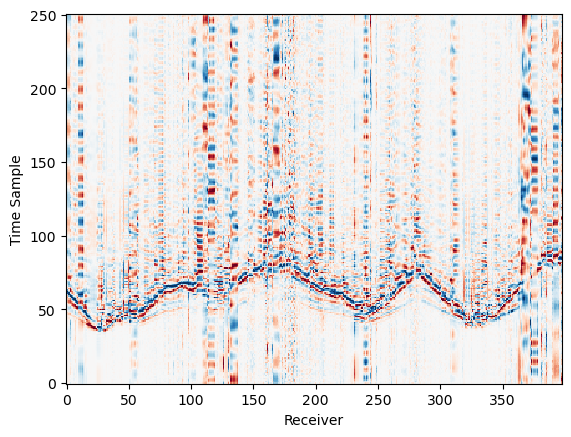

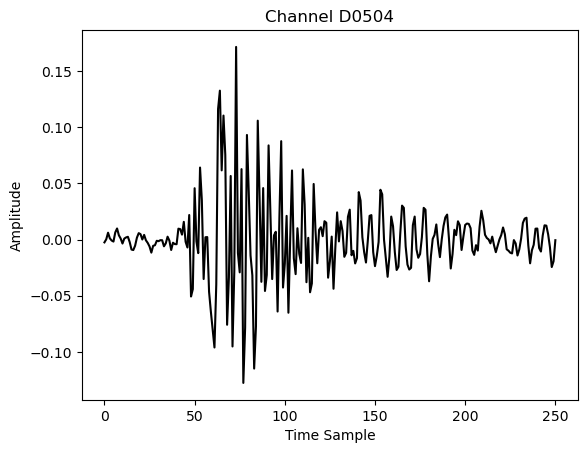

In [7]:
# And plot:
normalise_wavefield = True
plt.figure()
Y, X = np.meshgrid(np.arange(real_data_array.shape[1]), np.arange(real_data_array.shape[0]))
if normalise_wavefield:
    real_data_array_norm = np.zeros_like(real_data_array)
    for i in range(real_data_array.shape[0]):
        real_data_array_norm[i,:] = real_data_array[i,:] / np.max(np.abs(real_data_array[i,:]))
    plt.pcolormesh(X, Y, real_data_array_norm, cmap="RdBu", vmin=-1, vmax=1)
else:
    plt.pcolormesh(X, Y, real_data_array, cmap="RdBu", vmin=-np.max(np.abs(real_data_array)), vmax=np.max(np.abs(real_data_array)))
plt.ylabel("Time Sample")
plt.xlabel("Receiver")
plt.show()

# And plot a single channel:
channel_to_plot = 78
plt.figure()
plt.plot(real_data_array[channel_to_plot,:], 'k')
plt.title(f"Channel {recs[channel_to_plot]}")
plt.xlabel("Time Sample")
plt.ylabel("Amplitude")
plt.show()

## 3. Read in forward model data

- Read in pre-generated forward model data
- Note the six components! (Mxx, Myy, Mzz, Mxy, Mxz, Myz)
- Plot up an example synthetic wavefield and compare to observed data (hint: make up mix of components)

Note that we could generate forward model data here but it is computationally intensive (as run 3D spectral element method for 3D volume with 6 components).


(Note: forward model data generated using salvus. However, could be generated in any way).

In [8]:
# Code for running salvus to generate synthetics (not run here as computationally intensive):
# (included for completeness)

run_fwd = False # DO NOT CHANGE! CODE HERE DOES NOT WORK!

# Find starting model source-time-function and attenuation:
# (i.e. dominant frequency and Q)
allowable_f_range = [25,150]
vp = 3600.
mean_fmax, mean_Q, A0 = get_stf_and_attn_starting_model_params(real_data_array, recs, receivers_df, fs, nlloc_hyp_data, allowable_f_range=allowable_f_range, vp=vp)
print("Mean frequency:", mean_fmax, "Hz")
print("Mean Q:", mean_Q, "Hz")

# Define centre frequency for forward model STF:
centre_freq_Hz = mean_fmax

# And run Salvus to generate synthetics:
# Specify forward model parameters:
project_path = '/Volumes/4tb_extssd/salvus_tmp_workspace/src_inv' # (A temparory workspace!)
domain_dict = {'x0': -100.0, 'x1': 100.0, 'y0': -100.0, 'y1': 100.0, 'z0': -80.0, 'z1': 0.0}
gen_body_waves_only = False #True #False #False # (Not currently implemented!!!)
# xyz_src_m # Defined above
output_waveforms_settings_dict = {'output_fs_Hz': fs, 'gaussian_noise_dur_s': 0, 'snr_amp': 100.0, 'add_noise_to_signal': False, 'wfs_outdir' : os.path.join("data_out",event_uid)}
# Define the medium model:
# It helps to define the model larger than your domain to avoid
# edge effects during the model interpolation step.
nx = 100
x = np.linspace(-200, 200, nx)
y = np.linspace(-200, 200, nx)
z = np.linspace(-100, 200, nx)
xx, yy, zz = np.meshgrid(x, y, z, indexing="ij")
# Background model.
vp = 3540 * np.ones_like(xx) #3600 * np.ones_like(xx) #3840.0 * np.ones_like(xx)
vs = 1820 * np.ones_like(xx) #1845 * np.ones_like(xx) #1970.0 * np.ones_like(xx)
rho = 917.0 * np.ones_like(xx)
qkappa = 2 * mean_Q * np.ones_like(xx)
qmu = mean_Q * np.ones_like(xx)
medium_model_dict = {'vp': vp, 'vs': vs, 'rho': rho, 'qkappa': qkappa, 'qmu': qmu, 'x': x, 'y': y, 'z': z}

# Run salvus:
if run_fwd:
    gen_synths_salvus(project_path, domain_dict, xyz_src_m, receivers_df, medium_model_dict, centre_freq_Hz, output_waveforms_settings_dict=output_waveforms_settings_dict, gen_body_waves_only=gen_body_waves_only)




/Users/tomhudson/Documents/projects/gornergletscher_2023/skience_workshop/workshop_practicals/icequake_source_inversion/useful_functions.py:64: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hyp_dists[i] = np.sqrt(((nlloc_hyp_data.max_prob_hypocenter['x']*1000 - rec_row['x_m'])**2) + ((nlloc_hyp_data.max_prob_hypocenter['y']*1000 - rec_row['y_m'])**2) + ((nlloc_hyp_data.max_prob_hypocenter['z']*-1000 - rec_row['Elevation']*1000)**2))


Mean frequency: 98.16012332579231 Hz
Mean Q: 2.9522623189224824 Hz


/Users/tomhudson/Documents/projects/gornergletscher_2023/skience_workshop/workshop_practicals/icequake_source_inversion/useful_functions.py:109: RuntimeWarning: divide by zero encountered in divide
  Q_vec = trav_times / tstar_vec


In [9]:
# Read in forward modelled data:
# Load synthetic waveforms:
# (Data should already be converted to DAS orientations!)
synth_dir = os.path.join("inputs", "salvus_forward_model_data", event_uid)
synth_st_raw = obspy.Stream()
# Read in various model comps:
for Mcomp in ["Mxx", "Myy", "Mzz", "Mxy", "Mxz", "Myz"]:
    st_tmp = obspy.read(os.path.join(synth_dir, "*_0_"+Mcomp+".m")).select(channel="0")
    for i in range(len(st_tmp)):
        st_tmp[i].stats.channel = Mcomp
        st_tmp[i].stats.distance = float(st_tmp[i].stats.station[1:])
        synth_st_raw.append(st_tmp[i])
del st_tmp

# And zeropad data for synthetics to match real data:
for i in range(len(synth_st_raw)):
    synth_st_raw[i].data = np.concatenate((synth_st_raw[i].data, np.zeros(len(st[0].data) - len(synth_st_raw[i].data))))

# Apply a static time shift to the data:
# (to correct for real data pre padding)
for i in range(len(synth_st_raw)):
    synth_st_raw[i].data = np.roll(synth_st_raw[i].data, int(pre_post_pad[0]*st[0].stats.sampling_rate))



# And prep. data for inversion:
# (Note: Apply time-shifting (here rather than in inversion due to efficiency))
# (Note: Might introduce bias! (since shifting relative to one MT component))
# (Note: Strictly, any time-shifts and stretching should be applied during the inversion)
# (Note: Spatial downsampling occurs here!)

data_spat_downsamp_fac = 1 
perform_time_shift = True 
max_tshift_samp_lims = [-25,0]
Mcomp_to_use_as_ref = "Mxx" #"Mxx" # NOTE: Currently highly dependent on this value!
perform_tshift_on_pos_def_wfs = False #True #False # If True, takes absolute value of waveforms to remove polarity sensitivity for time shifts.
perform_tshift_on_wfs_envelope = False #True #False # (Potentially )
use_explosion = False #True # (Or use explosive source with amplitudes only?! - this works well for timing but not for inversion)

# Prep input data:
synth_st_in = synth_st_raw.copy() #synth_st_post_ts_and_str.copy() #synth_st_raw.copy()

# Load in modelled greens funcs:
# Shape is (n_rec, 6xMTcomps, n_tsamp)
recs = []
for i in range(len(synth_st_in)):
    if synth_st_in[i].stats.station not in recs:
        recs.append(synth_st_in[i].stats.station)
recs = np.array(recs)
# Downsample number of receivers if specified:
if not data_spat_downsamp_fac == 1:
    recs = recs[::int(data_spat_downsamp_fac)]
    
# Perform time shift on data:
if perform_time_shift:
    opt_time_shifts = []
    for station in recs:
        data = st.select(station=station)[0].data
        ###model = synth_st_in.select(station=station, channel=Mcomp_to_use_as_ref)[0].data
        if use_explosion:
            model = synth_st_in.select(station=station, channel="Mxx")[0].data + synth_st_in.select(station=station, channel="Myy")[0].data + synth_st_in.select(station=station, channel="Mzz")[0].data
        else:
            model = synth_st_in.select(station=station, channel=Mcomp_to_use_as_ref)[0].data
        # Perform time shift:
        nccs = np.zeros(max_tshift_samp_lims[1]-max_tshift_samp_lims[0])
        for i in range(len(nccs)):
            if perform_tshift_on_pos_def_wfs:
                nccs[i] = ncc(np.abs(data),np.roll(np.abs(model), int(max_tshift_samp_lims[0]+i)))
            else:
                nccs[i] = ncc(data,np.roll(model, int(max_tshift_samp_lims[0]+i)))
            if perform_tshift_on_wfs_envelope:
                analytic_data = hilbert(data)
                amplitude_data_envelope = np.abs(analytic_data)
                analytic_model = hilbert(model)
                amplitude_model_envelope = np.abs(analytic_model)
                nccs[i] = ncc(amplitude_data_envelope,np.roll(amplitude_model_envelope, int(max_tshift_samp_lims[0]+i)))
            else:
                nccs[i] = ncc(data,np.roll(model, int(max_tshift_samp_lims[0]+i)))
        opt_tshift_samp = int(max_tshift_samp_lims[0]) + int(np.argmax(nccs))
        opt_time_shifts.append(opt_tshift_samp)
        # And shift all model data by same time-shift:
        for Mcomp in ["Mxx", "Myy", "Mzz", "Mxy", "Mxz", "Myz"]:
            model_tmp = synth_st_in.select(station=station, channel=Mcomp)[0].data
            synth_st_in.select(station=station, channel=Mcomp)[0].data = np.roll(model_tmp, opt_tshift_samp)

n_rec = len(recs) # Number of receivers
tsamp_beg = np.zeros(len(synth_st_in[0].data))
tsamp_end = len(synth_st_in[0].data) * np.ones(n_rec)
green_func_array = np.zeros((n_rec, 6, int(tsamp_end[0]-tsamp_beg[0]))) # Shape is (n_rec, 6xMTcomps, n_tsamp)
for i in range(len(recs)):
    # Load data in NED convention order (and salvus positive up!):
    for Mcomp in ["Myy", "Mxx", "Mzz", "Mxy", "Myz", "Mxz"]:
        # Start with North:
        if Mcomp == "Myy":
            A = synth_st_in.select(station=recs[i], channel=Mcomp)[0].data
        else:
            # And deal with sign change for Z:
            if Mcomp in ("Mxz", "Myz"): 
                A = np.vstack((A, -1 * synth_st_in.select(station=recs[i], channel=Mcomp)[0].data))
            else:
                A = np.vstack((A, synth_st_in.select(station=recs[i], channel=Mcomp)[0].data))
    green_func_array[i, :, :] = A


/var/folders/hg/xp5sp5p14knc98zsdqx2p7cw0000gn/T/ipykernel_14755/4092594395.py:70: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nccs[i] = ncc(data,np.roll(model, int(max_tshift_samp_lims[0]+i)))
/var/folders/hg/xp5sp5p14knc98zsdqx2p7cw0000gn/T/ipykernel_14755/4092594395.py:78: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nccs[i] = ncc(data,np.roll(model, int(max_tshift_samp_lims[0]+i)))


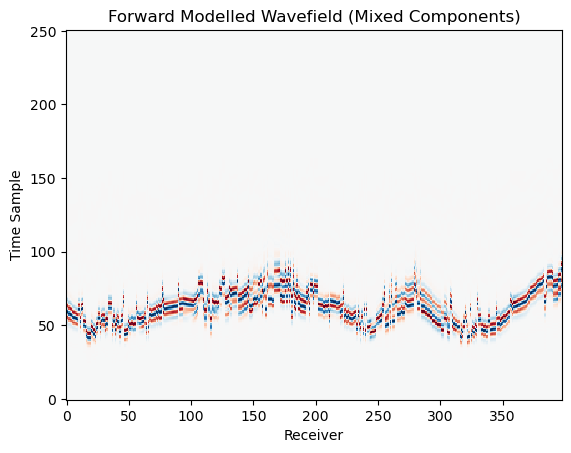

In [10]:
# And plot forward modelled waveforms:
# (Make up a mix of components to compare to real data)

mixing_coeffs = {'Mxx': 0.5, 'Myy': 0.3, 'Mzz': 0.2, 'Mxy': 0.0, 'Mxz': 0.0, 'Myz': 0.0}
synth_data_array = np.zeros((n_rec, n_tsamp))
for i in range(n_rec):
    synth_data_array[i,:] = (mixing_coeffs['Mxx'] * green_func_array[i, 0, :] +
                             mixing_coeffs['Myy'] * green_func_array[i, 1, :] +
                             mixing_coeffs['Mzz'] * green_func_array[i, 2, :] +
                             mixing_coeffs['Mxy'] * green_func_array[i, 3, :] +
                             mixing_coeffs['Mxz'] * green_func_array[i, 4, :] +
                             mixing_coeffs['Myz'] * green_func_array[i, 5, :] )
    
# And plot:
normalise_wavefield = True
plt.figure()
Y, X = np.meshgrid(np.arange(synth_data_array.shape[1]), np.arange(synth_data_array.shape[0]))
if normalise_wavefield:
    synth_data_array_norm = np.zeros_like(synth_data_array)
    for i in range(synth_data_array.shape[0]):
        synth_data_array_norm[i,:] = synth_data_array[i,:] / np.max(np.abs(synth_data_array[i,:]))
    plt.pcolormesh(X, Y, synth_data_array_norm, cmap="RdBu", vmin=-1, vmax=1)
else:
    plt.pcolormesh(X, Y, synth_data_array, cmap="RdBu", vmin=-np.max(np.abs(synth_data_array)), vmax=np.max(np.abs(synth_data_array)))
plt.ylabel("Time Sample")
plt.xlabel("Receiver")
plt.title("Forward Modelled Wavefield (Mixed Components)")
plt.show()

## 4. Perform inversion:

- Understand theory behind the inversion procedure
- Understand practically how to set it up and run it

In [11]:
# Check sizes of arrays:
# (should have same number of sources and time samples!)
print(real_data_array.shape, green_func_array.shape)

(398, 251) (398, 6, 251)


In [12]:
# Define function to perform inversion:
def perform_inversion(real_data_array, green_func_array, return_uncorr_cov_matrix=False):
    """Function to perform least sqauraes inversion using real data and greens functions to obtain the moment tensor. (See Walter 2009 thesis, Appendix C for theoretical details).
    Inputs are: real_data_array - array of size (k,t_samples), containing real data to invert for; green_func_array - array of size (k, n_mt_comp, t_samples), containing the greens function data for the various mt components and each station (where k is the number of stations*station components to invert for, t_samples is the number of time samples, and n_mt_comp is the number of moment tensor components specficied in the greens functions array).
    Outputs are: M - tensor of length n_mt_comp, containing the moment tensor (or single force) inverted for."""
    # Perform the inversion:
    D = np.transpose(np.array([np.hstack(list(real_data_array[:]))])) # equivilent to matlab [real_data_array[0]; real_data_array[1]; real_data_array[2]]
    G =  np.transpose(np.vstack(np.hstack(list(green_func_array[:])))) # equivilent to matlab [green_func_array[0]; green_func_array[1]; green_func_array[2]]
    M, res, rank, sing_values_G = np.linalg.lstsq(G,D) # Equivilent to M = G\D; for G not square. If G is square, use linalg.solve(G,D)
    if return_uncorr_cov_matrix:
        var = res / (len(D) - len(M))
        # cov_M = np.zeros((6,6))
        # np.fill_diagonal(cov_M, vars)
        GtG_inv = np.linalg.inv(G.T @ G)
        cov_M = var * GtG_inv
        return M, cov_M
    else:
        return M

In [13]:
# Perform least-squares inversion:
MT_lsq, cov_MT_lsq = perform_inversion(real_data_array, green_func_array, return_uncorr_cov_matrix=True)
print("MT result:", MT_lsq)
# print("Uncorrelated covariance matrix of MT result:", cov_MT_lsq)
print("Standard deviations of parameters:", np.sqrt(np.diagonal(cov_MT_lsq)))


MT result: [[ 2.57495018e+13]
 [ 6.57716082e+13]
 [ 9.11452836e+12]
 [-4.92259655e+11]
 [ 5.75991104e+11]
 [ 1.81336697e+12]]
Standard deviations of parameters: [2.00443436e+12 2.07843087e+12 1.60336457e+12 6.08324990e+11
 4.10055696e+11 3.33270488e+11]


## 5. Plot up results:

- Plot inversion results
- Interpret what they mean
- Why did we get to this result?
- Are there any biases in our processing steps?
- What information could improve the result?


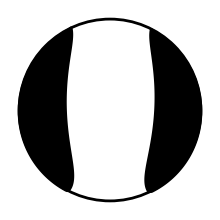

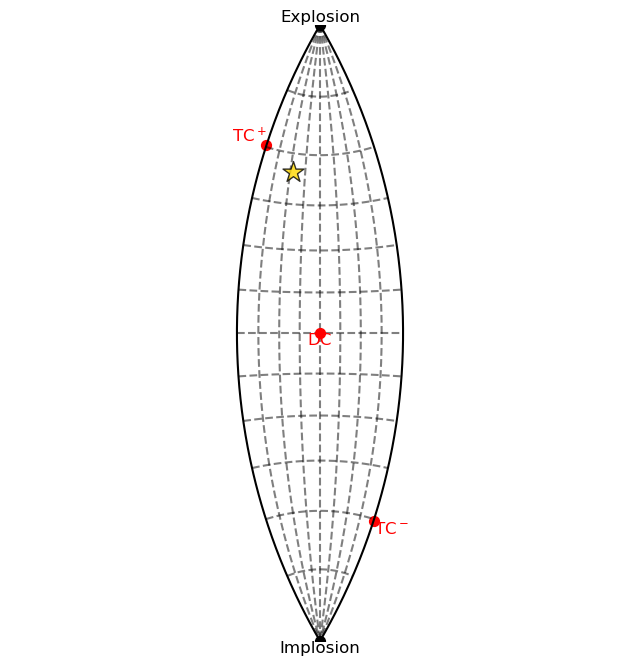

In [15]:
# And plot result:
MT_use = mt_ned2use(MT_lsq)
beachball(MT_use.flatten(), size=200, linewidth=2, bgcolor='w', facecolor='k')
# And plot Lune:
SeisSrcInv.plot.plot_Lune([], [], six_MT_max_prob=MT_lsq[:,0])
# And plot full waveform result (if desired):
# SeisSrcInv.plot.plot_full_waveform_result_beachball(MT_lsq, {}, radiation_pattern_MT=MT_lsq[:,0], MTp_max_prob_value=-1, stations=[], lower_upper_hemi_switch="upper", figure_filename=[], num_MT_solutions_to_plot=20, inversion_type="unconstrained", radiation_MT_phase="P", plot_plane="EN", plot_uncertainty_switch=False, uncertainty_MTs=[], uncertainty_MTp=[], plot_wfs_on_focal_mech_switch=False, DC_switch_slip_vector=False, fig=None, ax=None)


## 6. Explore improvements or follow on investigations...

- What improvements could be made to the current workflow?
- How might one overcome certain limitations or assumptions made?
- What follow on investigations might be interesting to learn more about the icequake source?